In [30]:
%load_ext autoreload
%autoreload 2

In [ ]:
from benchmark import run_benchmarks, plot_benchmark_results
import matplotlib.pyplot as plt

## Chunked writing/reading

# Benchmark

Adapted from https://github.com/giovp/spatialdata-sandbox/blob/main/notebooks/benchmark_geoparquet_encoding.ipynb

In [80]:
## Config
# Point numbers to benchmark
# N_POINTS = [500_000, 1_000_000, 10_000_000]
N_POINTS = [50_000, 100_000, 500_000]

# Numbers of genes to benchmark
N_GENES = [1000, 10_000, 20_000]

# Number of repetitions for each benchmark
N_REPS = 3

# Methods to compare
METHODS = ["polars", "multiscale"]

In [ ]:
results = run_benchmarks(METHODS, N_GENES, N_POINTS, N_REPS)

Using temp directory: C:\Users\stock\AppData\Local\Temp\tmpbvd0ir34

Benchmarking size: 50,000 with 1000 genes.
    polars - size: 1.3 MB
    polars - metadata size: 3.16 KB
    polars - writing: 0.0351s
    polars - gene query: 0.0022s
    polars - bounding box query: 0.0088s
    multiscale - size: 5.71 MB
    multiscale - metadata size: 2635.4 KB
    multiscale - writing: 1.2031s
    multiscale - gene query: 0.1027s
    multiscale - bounding box query: 0.2822s

Benchmarking size: 50,000 with 10000 genes.
    polars - size: 1.37 MB
    polars - metadata size: 3.16 KB
    polars - writing: 0.0378s
    polars - gene query: 0.0021s
    polars - bounding box query: 0.0082s
    multiscale - size: 28.33 MB
    multiscale - metadata size: 15640.83 KB
    multiscale - writing: 9.1114s
    multiscale - gene query: 0.9765s
    multiscale - bounding box query: 1.7956s

Benchmarking size: 50,000 with 20000 genes.
    polars - size: 1.41 MB
    polars - metadata size: 3.16 KB
    polars - writing:

In [87]:
results
display(results.pivot_table(
    index=["size", "n_genes", "method"],
    values=["file_size", "meta_size", "writing_mean", "bb_query_mean", "gene_query_mean"]
).round(4))

bb_query_mean  file_size  gene_query_mean  \
size   n_genes method                                                  
50000  1000    multiscale         0.2822       5.71           0.1027   
               polars             0.0088       1.30           0.0022   
       10000   multiscale         1.7956      28.33           0.9765   
               polars             0.0082       1.37           0.0021   
       20000   multiscale         2.8928      40.01           1.6635   
               polars             0.0148       1.41           0.0035   
100000 1000    multiscale         0.8057       8.14           0.2330   
               polars             0.0126       2.62           0.0155   
       10000   multiscale         3.2600      40.93           1.6433   
               polars             0.0244       2.71           0.0039   
       20000   multiscale         4.5815      61.75           2.6277   
               polars             0.0115       2.77           0.0046   
500000 1000    multiscale         1.2211      18.67           0.2762   
               polars             0.0236      10.93           0.0112   
       10000   multiscale         6.2375      66.82           2.3527   
               polars             0.0236      11.21           0.0101   
       20000   multiscale         9.4988     108.44           4.5106   
               polars             0.0337      11.31           0.0096   

                           meta_size  writing_mean  
size   n_genes method                               
50000  1000    multiscale    2635.40        1.2031  
               polars           3.16        0.0351  
       10000   multiscale   15640.83        9.1114  
               polars           3.16        0.0378  
       20000   multiscale   22383.95       15.6104  
               polars           3.16        0.0941  
100000 1000    multiscale    3366.86        3.4331  
               polars           3.16        0.1259  
       10000   multiscale   22193.29       16.0948  
               polars           3.16        0.1319  
       20000   multiscale   34196.14       24.2576  
               polars           3.16        0.1290  
500000 1000    multiscale    4144.44        9.2603  
               polars           3.19        0.3413  
       10000   multiscale   31031.43       27.1978  
               polars           3.19        0.3588  
       20000   multiscale   54881.80       43.9136  
               polars           3.19        0.3371

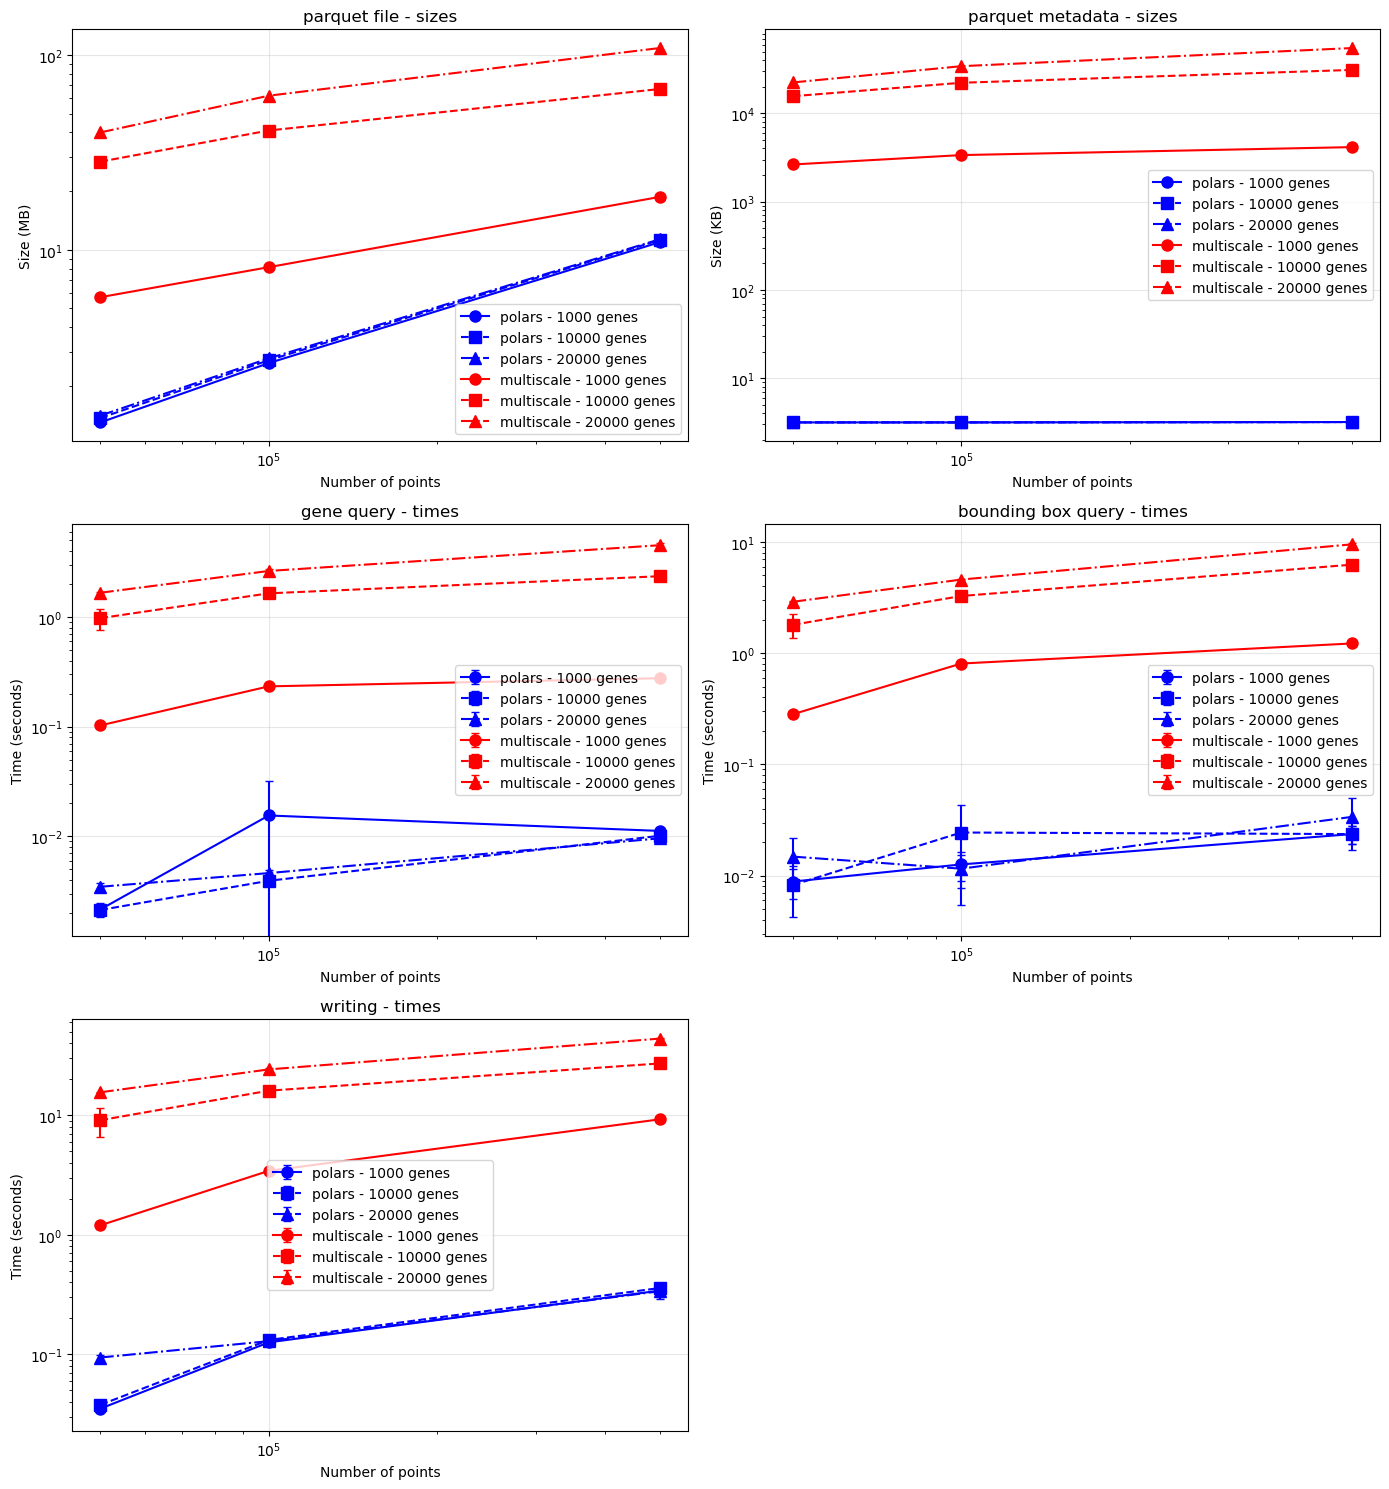

In [ ]:
fig = plot_benchmark_results(results, METHODS, N_GENES)
plt.show()